# **Data Exploration**
The purpose of this notebook is to explore the onhand IEEE-CIS Fraud Detection dataset.

The exploration aims to
- check the format of the data
- check for important columns and properties for later feature engineering and modell development
- check similarities and patterns

### Imports

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Merge both datasets on Transaction ID column

In [3]:
train_trans = pd.read_csv("../data/raw/train_transaction.csv")
train_id = pd.read_csv("../data/raw/train_identity.csv")

df = pd.merge(train_trans, train_id, how="left", on="TransactionID") # left (trans) = dominant df, transaction id = identifier

In [4]:
df.head()
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Total rows: 590540, Total columns: 434


In [5]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [6]:
df.shape

(590540, 434)

we can see that the dataset consist of 590 000 rows with each 394 columns

In [7]:
# Alle Spaltennamen gruppiert ausgeben
print("Transaction:", train_trans.columns.tolist())
print("Identity:", train_id.columns.tolist())

Transaction: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V8

In [8]:
df.groupby('id_38')['isFraud'].mean()

id_38
F    0.097792
T    0.059541
Name: isFraud, dtype: float64

## Column Overview

### Transaction
- Transaction ID = Unique id per payment
- isFraud = our y value
- TransactionDT = time in seconds 
- TransactionAmt = payment amount in usd. Sometimes 3 digits after ,. This is because of currency swapping
- ProductCD = product Code ( any kind of service )
- card1 - card6 = payment card information
- addr1 = purchaser billing region (anonymized)
- addr2 = purchaser billing country (anonymized)
- dist1 / dist2 = distances -- between purchaser and seller?
- p_emaildomain = purchaser email domain
- R_emaildomain = recipient email domain (optional)
- C1-C14 = meaning is masked
- D1-D15 = time information: time between this and last transaction...
    - D9 * 24 = hours
- M1-M9 = match of card name and address, boolean values
- V1-V339 = Masked information (numerical)

## Identity 
- Id01-Id38 = Identity Columns (masked)
- Id_28 = Is device/user known in system (New / Found)
- Id_29 = Is device/user known in system (New / Found)
- Id_30 = Operating System
- Id_31 = Browser
- Id_35 = Unknown boolean flag – F correlates 3x higher with fraud (likely security feature disabled)
- Id_36 = Unknown boolean flag – F correlates 2x higher with fraud (likely security feature disabled)
- DeviceType = Mobile, Desktop...
- DeviceInfo = Device Name

## **Utilize not numerical columns**

In [45]:
print(df.select_dtypes(include="str").shape[1])

31


In [53]:
results_ohe = []
results_freq = []

for col in df.select_dtypes(include="str").columns:
    n_unique = df[col].nunique()
    most_common = df[col].value_counts().iloc[0]
    entry = f"{col}: {n_unique} unique, most common {most_common}x"
    
    if n_unique <= 10:
        results_ohe.append(entry)
    else:
        results_freq.append(entry)


In [54]:
print("=== OHE ===")
print("\n".join(results_ohe))

=== OHE ===
ProductCD: 5 unique, most common 439670x
card4: 4 unique, most common 384767x
card6: 4 unique, most common 439938x
M1: 2 unique, most common 319415x
M2: 2 unique, most common 285468x
M3: 2 unique, most common 251731x
M4: 3 unique, most common 196405x
M5: 2 unique, most common 132491x
M6: 2 unique, most common 227856x
M7: 2 unique, most common 211374x
M8: 2 unique, most common 155251x
M9: 2 unique, most common 205656x
id_12: 2 unique, most common 123025x
id_15: 3 unique, most common 67728x
id_16: 2 unique, most common 66324x
id_23: 3 unique, most common 3489x
id_27: 2 unique, most common 5155x
id_28: 2 unique, most common 76232x
id_29: 2 unique, most common 74926x
id_34: 4 unique, most common 60011x
id_35: 2 unique, most common 77814x
id_36: 2 unique, most common 134066x
id_37: 2 unique, most common 110452x
id_38: 2 unique, most common 73922x
DeviceType: 2 unique, most common 85165x


In [55]:
print("\n=== Frequency ===")
print("\n".join(results_freq))


=== Frequency ===
P_emaildomain: 59 unique, most common 228355x
R_emaildomain: 60 unique, most common 57147x
id_30: 75 unique, most common 21155x
id_31: 130 unique, most common 22000x
id_33: 260 unique, most common 16874x
DeviceInfo: 1786 unique, most common 47722x


we apply OHE to each column with less than 10 unique values and apply frequency encoding to the ones with more than 10

## **Check Fraud Rate for Specific Columns**

### Correlation to fraud Overview and Heatmap

In [9]:
corr = df.select_dtypes(include="number").corr()["isFraud"].sort_values(ascending=False)

print(corr.head(20))
print(corr.tail(20))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64
D4      -0.067216
V36     -0.069875
V11     -0.071950
D10     -0.072002
V10     -0.074658
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
Name: isFraud, dtype: float64


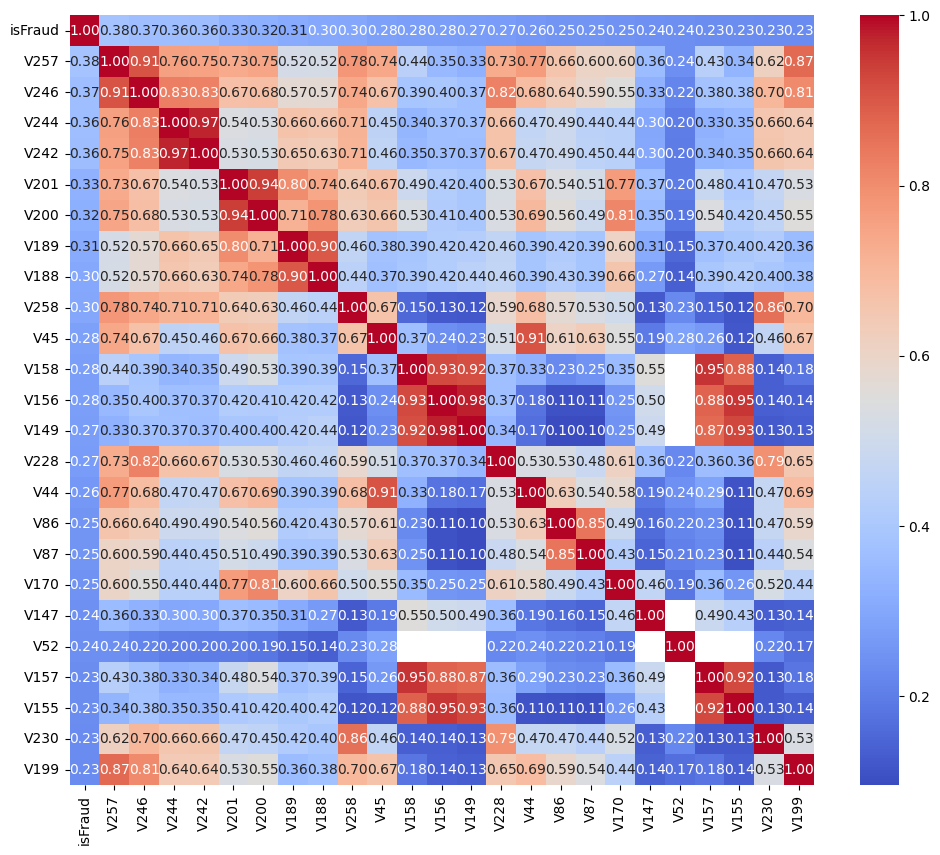

In [10]:
top_features = corr.abs().sort_values(ascending=False).head(25).index

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

V features are the strongest indicator for us, wether a payment is fraudly or not. V features also strongly correlate with each other

### **Check for correlation to specific products**

ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64


<Axes: xlabel='ProductCD'>

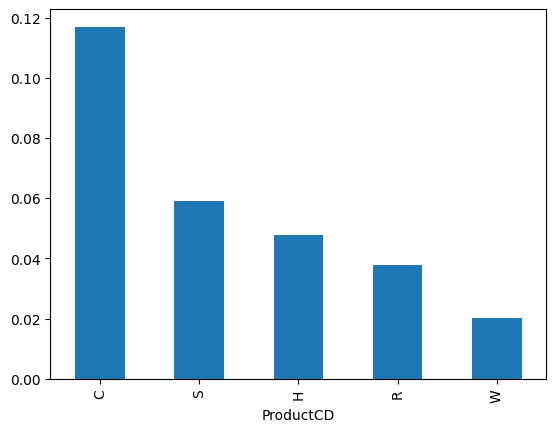

In [11]:
print(df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False))
df.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')

# we can clearly see, that product c has the highest rate of fraud. Likelihood of fraud payment is more than 2x compared to other products

In [12]:
df["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

the plot above shows us, that Product c strongly correlates with elevated risk. The other products slightly differ in their fraud risk, but only in dimensions of 1-2. However, product c is outstanding with almost 12% fraud risk.

### **check for correlation to specific amounts**

TransactionAmtBin
(0.25, 30.199]         0.050900
(30.199, 48.95]        0.030732
(48.95, 59.0]          0.021435
(59.0, 92.0]           0.042046
(92.0, 117.0]          0.022573
(117.0, 210.95]        0.040446
(210.95, 31937.391]    0.047088
Name: isFraud, dtype: float64
mean price:  135.02717637247264


/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/1556825337.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["TransactionAmtBin"] = pd.qcut(df["TransactionAmt"], q=7)


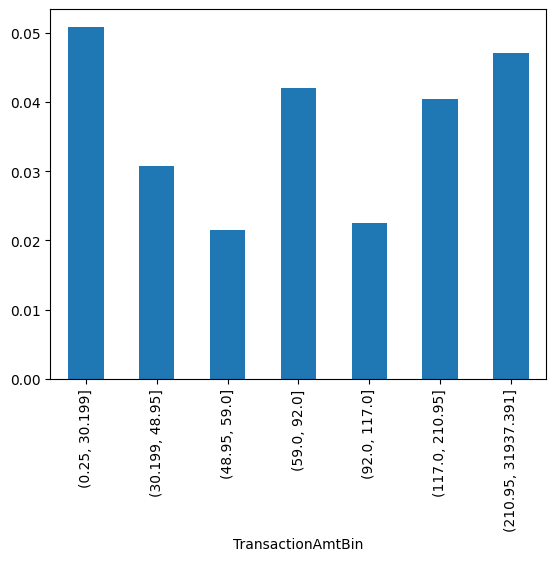

In [13]:
df["TransactionAmtBin"] = pd.qcut(df["TransactionAmt"], q=7)

print(df.groupby("TransactionAmtBin")["isFraud"].mean())

print("mean price: ",df["TransactionAmt"].mean())

df.groupby("TransactionAmtBin")["isFraud"].mean().plot(kind="bar")

df = df.drop("TransactionAmtBin", axis=1)

price - fraud correlation nearly looks u shaped. Based on this we can conclude, that the most fraud activity is conducted with very low amounts (<30) or very high amounts (>210). Also visible is the outlier in the middle (59-92) which also has higher fraud risk.

### **check for correlation to specific email provider**

R_emaildomain_grouped
outlook.com      0.165138
icloud.com       0.128755
gmail.com        0.119184
hotmail.com      0.077793
yahoo.com        0.051512
aol.com          0.034855
anonymous.com    0.029130
other            0.021101
comcast.net      0.011589
yahoo.com.mx     0.010610
msn.com          0.001174
Name: isFraud, dtype: float64


/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/1073196804.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['R_emaildomain_grouped'] = df['R_emaildomain'].apply(


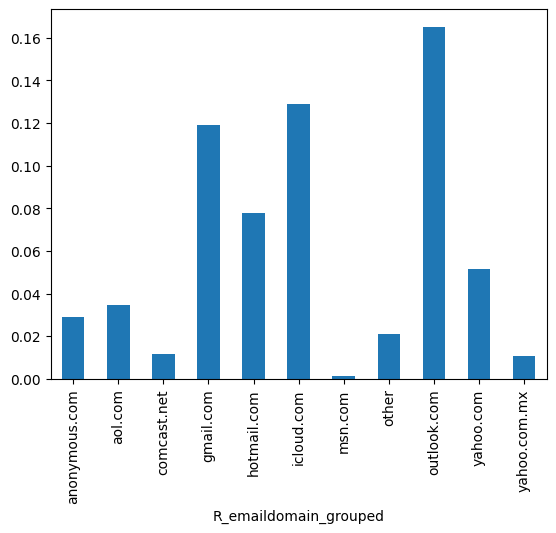

In [14]:
# List of top providers (6 top providers)
top_providers = df['R_emaildomain'].value_counts().head(10).index


# add bin property from top provider or apply "other"
df['R_emaildomain_grouped'] = df['R_emaildomain'].apply(
    lambda x: x if x in top_providers else 'other'
)

# Fraud rate for every provider
print(df.groupby('R_emaildomain_grouped')['isFraud'].mean().sort_values(ascending=False))

df.groupby('R_emaildomain_grouped')['isFraud'].mean().plot(kind="bar")

df = df.drop("R_emaildomain_grouped",axis=1)


we can conclude that the most fraud is being conducted with commonly used email addess - providers. Outstanding is the very elevated fraud risk ov outlook mail recipants

In [15]:
df["R_emaildomain"].isna().sum()

np.int64(453249)

In [16]:
df["R_emaildomain"].unique()

<StringArray>
[               nan,        'gmail.com',      'hotmail.com',
      'outlook.com',    'anonymous.com',      'charter.net',
   'prodigy.net.mx',      'comcast.net',      'live.com.mx',
       'icloud.com',        'yahoo.com',          'aol.com',
         'juno.com',          'att.net',      'verizon.net',
     'yahoo.com.mx',    'bellsouth.net', 'servicios-ta.com',
        'ymail.com',       'hotmail.es',          'msn.com',
    'optonline.net',         'live.com',           'gmx.de',
          'aim.com',         'mail.com',           'me.com',
       'outlook.es',          'cox.net',    'earthlink.net',
   'embarqmail.com',           'web.de',    'sbcglobal.net',
     'scranton.edu',          'mac.com',          'twc.com',
   'roadrunner.com',         'yahoo.fr',         'yahoo.de',
         'yahoo.es',  'frontiernet.net',            'gmail',
          'live.fr',            'q.com',      'yahoo.co.uk',
   'windstream.net',   'suddenlink.net',       'hotmail.fr',
          

### **check for correlation to specific browser**

                            fraud_rate  count
id_31                                        
chrome 63.0                   0.068318  22000
mobile safari 11.0            0.062728  13423
mobile safari generic         0.099878  11474
ie 11.0 for desktop           0.019380   9030
safari generic                0.025015   8195
chrome 62.0                   0.041632   7182
chrome 65.0                   0.098821   6871
chrome 64.0                   0.091641   6711
chrome 63.0 for android       0.112470   5806
chrome generic                0.168062   4778
chrome 66.0                   0.093340   4264
edge 16.0                     0.027459   4188
chrome 64.0 for android       0.158940   3473
chrome 65.0 for android       0.147182   3336
firefox 57.0                  0.055505   3315
mobile safari 10.0            0.046060   2779
chrome 66.0 for android       0.129842   2349
chrome 62.0 for android       0.076776   2097
edge 15.0                     0.038125   1600
chrome generic for android    0.10

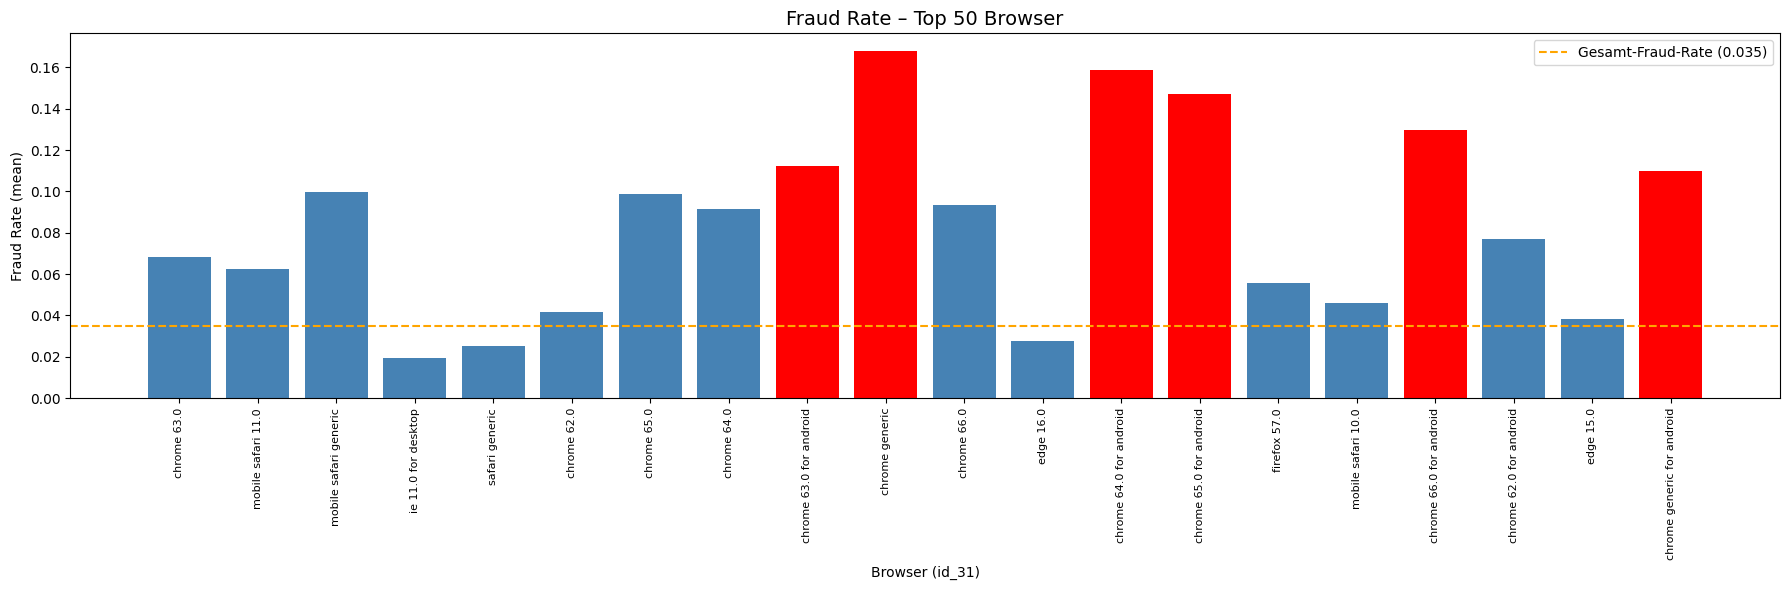

In [17]:
top20_browsers = (
    df.groupby('id_31')
    .agg(
        fraud_rate=('isFraud', 'mean'),
        count=('isFraud', 'count')
    )
    .sort_values('count', ascending=False)  
    .head(20)
)

print(top20_browsers)

fig, ax = plt.subplots(figsize=(18, 6))

bars = ax.bar(
    range(len(top20_browsers)),
    top20_browsers['fraud_rate'],
    color=['red' if r > 0.1 else 'steelblue' for r in top20_browsers['fraud_rate']] # if fraud rate more than 10%
)

# X-Axis: Browser Names
ax.set_xticks(range(len(top20_browsers)))
ax.set_xticklabels(top20_browsers.index, rotation=90, fontsize=8)

ax.set_title('Fraud Rate – Top 50 Browser', fontsize=14)
ax.set_ylabel('Fraud Rate (mean)')
ax.set_xlabel('Browser (id_31)')
ax.axhline(y=df['isFraud'].mean(), color='orange', linestyle='--', label=f'Gesamt-Fraud-Rate ({df["isFraud"].mean():.3f})')
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
df['id_31'].isna().mean() * 100 # how much percent of the data has NaN values for browser

np.float64(76.24513157449114)

In [40]:
df["id_31"].nunique()

130

In [37]:
df["id_31"].value_counts().head(10)

id_31
chrome 63.0                22000
mobile safari 11.0         13423
mobile safari generic      11474
ie 11.0 for desktop         9030
safari generic              8195
chrome 62.0                 7182
chrome 65.0                 6871
chrome 64.0                 6711
chrome 63.0 for android     5806
chrome generic              4778
Name: count, dtype: int64

we can see a relatively high cardinality with some browser appearing way more often than others. This is a good candidate for frequency encoding

## **Check for correlation to specific card types**

card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64
number of transactions by provider:  card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64


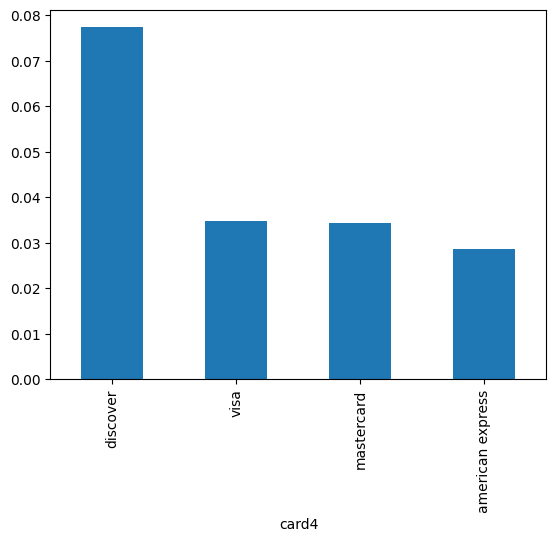

In [19]:
print(df.groupby('card4')['isFraud'].mean().sort_values(ascending=False))
df.groupby('card4')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')

print("number of transactions by provider: ", df["card4"].value_counts())

based on the plot and the print above, we can intepret that the payment provider discover has an increased risk for fraud activity. The provider is twice as risky as other alternatives, but only used by a very small amount of transactions <7000 in out dataset. 

card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64
card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64


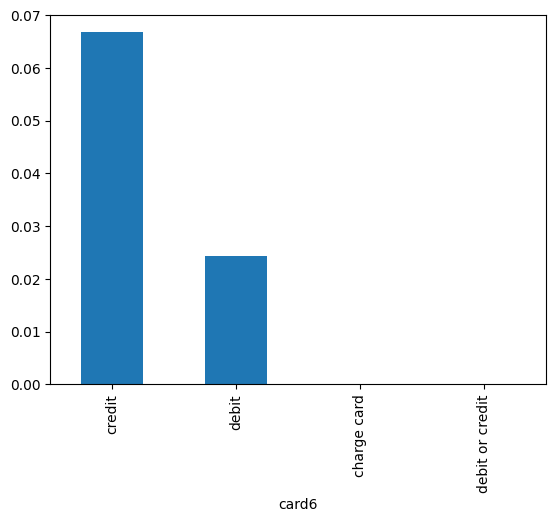

In [20]:
print(df.groupby("card6")["isFraud"].mean().sort_values(ascending=False))
df.groupby("card6")["isFraud"].mean().sort_values(ascending=False).plot(kind="bar")
print(df["card6"].value_counts())

we can see an increased amount of fraud for credit cards compared to debit cards, which is more than twice the amount

## **Check for Address values**

In [21]:
df["addr2"].value_counts()

addr2
87.0    520481
60.0      3084
96.0       638
32.0        91
65.0        82
         ...  
82.0         1
89.0         1
94.0         1
55.0         1
93.0         1
Name: count, Length: 74, dtype: int64

       fraud_rate   count
addr2                    
10.0     1.000000       8
82.0     1.000000       1
51.0     1.000000       4
46.0     1.000000       3
92.0     1.000000       2
75.0     1.000000       1
38.0     0.666667       3
65.0     0.536585      82
36.0     0.500000       2
54.0     0.333333       6
73.0     0.200000       5
96.0     0.139498     638
68.0     0.100000      10
29.0     0.090909      11
60.0     0.090467    3084
32.0     0.065934      91
87.0     0.023972  520481
94.0     0.000000       1
62.0     0.000000       4
63.0     0.000000       2
101.0    0.000000       4
100.0    0.000000       2
66.0     0.000000       2
98.0     0.000000      11
97.0     0.000000       2
69.0     0.000000      17
70.0     0.000000       1
71.0     0.000000       7
83.0     0.000000       1
84.0     0.000000       1


<Axes: xlabel='addr2'>

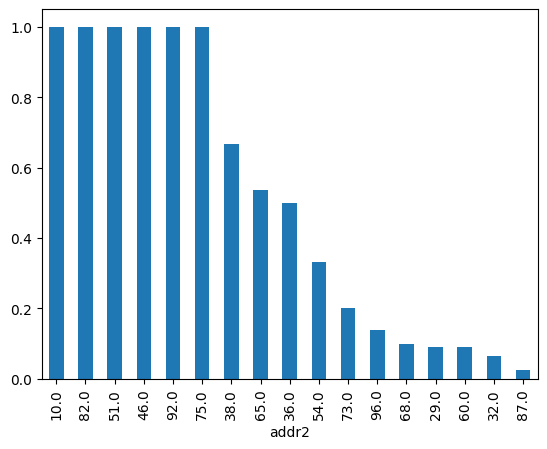

In [22]:
print(df.groupby('addr2').agg( # create temporary df 
    fraud_rate=('isFraud', 'mean'), # fraud_rate Column with mean value of isFraud
    count=('isFraud', 'count') # count value with number of isFraud entry per group
    ).sort_values('fraud_rate', ascending=False).head(30)) 

df.groupby("addr2")["isFraud"].mean().sort_values(ascending=False).head(17).plot(kind="bar")

we can see in the print above that we have 74 different purchaser countries in the dataset. However, only 17 do have reported fraud activity. The 

as 87 for billing country (addr2) is the most often, we can interpret that this value corresponds to usa

## **Check for null values**

In [23]:
null_rates = df.isnull().mean().sort_values(ascending=False).head(30)
print(null_rates[null_rates>0.1])


id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
id_09    0.873123
D9       0.873123
D8       0.873123
id_30    0.868654
id_32    0.868619
id_34    0.868248
id_14    0.864456
V142     0.861237
V158     0.861237
V140     0.861237
dtype: float64


In [24]:
print("Columns > 50% NaN:", (null_rates > 0.5).sum())
print("Columns > 90% NaN:", (null_rates > 0.9).sum())
print("Columns > 95% NaN:", (null_rates > 0.95).sum())

Columns > 50% NaN: 30
Columns > 90% NaN: 12
Columns > 95% NaN: 9


we see, that we have multiple columns having minimal to none impact because of nearly always being absent.

# **Time Interpretation**

In [25]:
df["TransactionDT"].head()

0    86400
1    86401
2    86469
3    86499
4    86506
Name: TransactionDT, dtype: int64

first entry = 86400 wich is the exact amount of seconds of 24h 
that lets us conclude, that the given column is represented in unit seconds

=> based on this we than can create day (/86400) and hour columns (/3600)

In [26]:
# // always rounding to the smaller int 
# % = wenn rest, dann returne nur rest

df["DT_day"] = df["TransactionDT"] // 86400
df["DT_hour"] = (df["TransactionDT"] // 3600) % 24
df["weekday"] = df["DT_day"] % 7

/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/2565152040.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DT_day"] = df["TransactionDT"] // 86400
/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/2565152040.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DT_hour"] = (df["TransactionDT"] // 3600) % 24
/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/2565152040.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

<Axes: xlabel='weekday'>

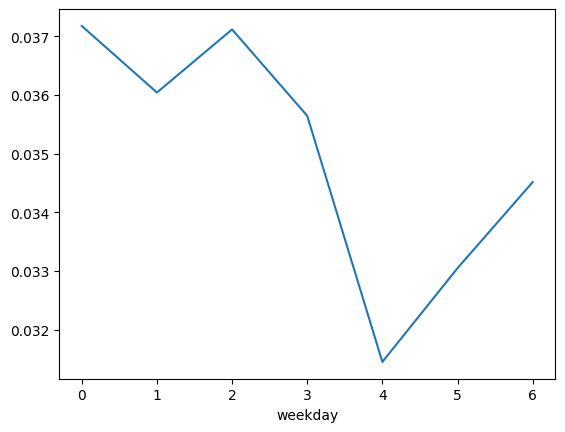

In [27]:
df.groupby("weekday")["isFraud"].mean().plot()

<Axes: xlabel='DT_hour'>

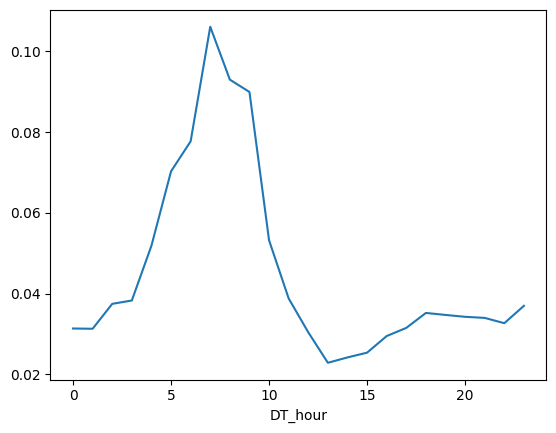

In [28]:
df.groupby("DT_hour")["isFraud"].mean().plot()

In [29]:
df = df.drop(["DT_hour", "weekday"], axis=1)

we can see clear patterns for increased fraud activity in hours 22-7. Weekdays are also strongly indicating that from day 4 to day 2 fraud activity is increasing and then drastically decreases. Most likely indicating that day 3 is a saturday and day 4 a sunday

# **Distance Values**

In [30]:
df["dist2"].describe()

count    37627.000000
mean       231.855423
std        529.053494
min          0.000000
25%          7.000000
50%         37.000000
75%        206.000000
max      11623.000000
Name: dist2, dtype: float64

dist1Bin
(-10.286, 1028.6]    0.019764
(1028.6, 2057.2]     0.025451
(2057.2, 3085.8]     0.024155
(3085.8, 4114.4]     0.031496
(4114.4, 5143.0]     0.016529
(5143.0, 6171.6]     0.000000
(6171.6, 7200.2]     0.000000
(7200.2, 8228.8]     0.000000
(9257.4, 10286.0]    0.000000
Name: isFraud, dtype: float64


/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/1877979491.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist1Bin"] = pd.cut(df["dist1"],bins = 10,)


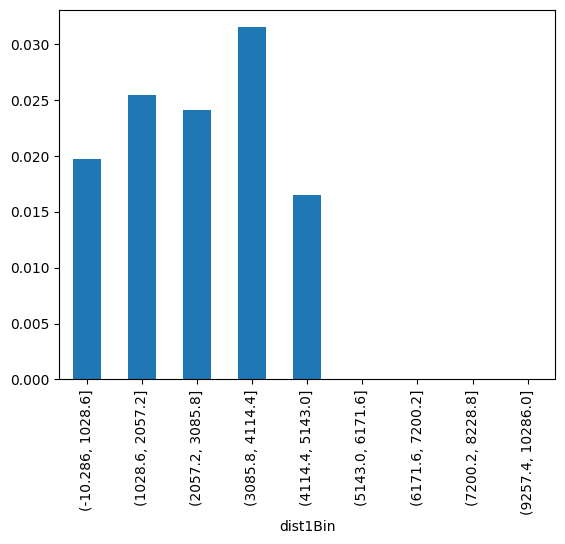

In [31]:
df["dist1Bin"] = pd.cut(df["dist1"],bins = 10,)
print(df.groupby("dist1Bin")["isFraud"].mean())

df.groupby("dist1Bin")["isFraud"].mean().plot(kind="bar")
df = df.drop("dist1Bin", axis=1)


dist2Bin
(-11.623, 1162.3]     0.101689
(1162.3, 2324.6]      0.047843
(2324.6, 3486.9]      0.010601
(3486.9, 4649.2]      0.000000
(4649.2, 5811.5]      0.162791
(5811.5, 6973.8]      0.166667
(6973.8, 8136.1]      0.000000
(8136.1, 9298.4]      0.000000
(9298.4, 10460.7]     0.333333
(10460.7, 11623.0]    0.000000
Name: isFraud, dtype: float64


/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/2191864223.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dist2Bin"] = pd.cut(df["dist2"],bins = 10,)


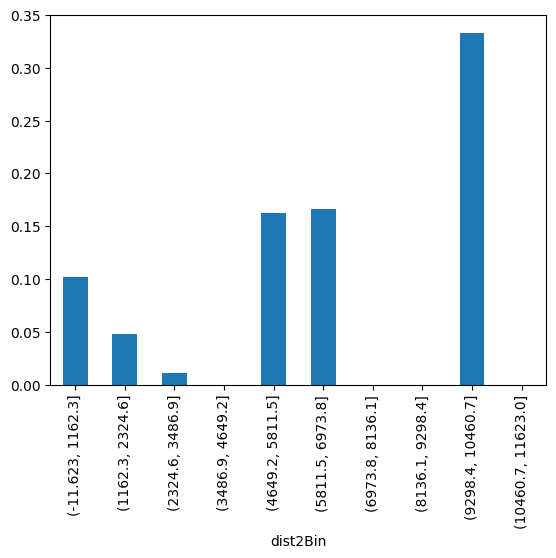

In [32]:
df["dist2Bin"] = pd.cut(df["dist2"],bins = 10,)
print(df.groupby("dist2Bin")["isFraud"].mean())

df.groupby("dist2Bin")["isFraud"].mean().plot(kind="bar")
df = df.drop("dist2Bin", axis=1)

In [33]:
df["card1"].value_counts().head(10)


card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
Name: count, dtype: int64

## Object Columns with high cardinality
Potential Columns for frequency encoding

In [43]:
df.select_dtypes(include="object").nunique()

/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/251659734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


ProductCD           5
card4               4
card6               4
P_emaildomain      59
R_emaildomain      60
M1                  2
M2                  2
M3                  2
M4                  3
M5                  2
M6                  2
M7                  2
M8                  2
M9                  2
id_12               2
id_15               3
id_16               2
id_23               3
id_27               2
id_28               2
id_29               2
id_30              75
id_31             130
id_33             260
id_34               4
id_35               2
id_36               2
id_37               2
id_38               2
DeviceType          2
DeviceInfo       1786
dtype: int64

In [42]:
for col in df.select_dtypes(include="object").columns:
    n_unique = df[col].nunique()
    most_common = df[col].value_counts().iloc[0]
    print(f"{col}: {n_unique} unique values, most common value appears {most_common}x times")


/var/folders/4m/khzpjqdj6cl07kznw50hb5780000gn/T/ipykernel_70882/1813610080.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


ProductCD: 5 unique values, most common value appears 439670x times
card4: 4 unique values, most common value appears 384767x times
card6: 4 unique values, most common value appears 439938x times
P_emaildomain: 59 unique values, most common value appears 228355x times
R_emaildomain: 60 unique values, most common value appears 57147x times
M1: 2 unique values, most common value appears 319415x times
M2: 2 unique values, most common value appears 285468x times
M3: 2 unique values, most common value appears 251731x times
M4: 3 unique values, most common value appears 196405x times
M5: 2 unique values, most common value appears 132491x times
M6: 2 unique values, most common value appears 227856x times
M7: 2 unique values, most common value appears 211374x times
M8: 2 unique values, most common value appears 155251x times
M9: 2 unique values, most common value appears 205656x times
id_12: 2 unique values, most common value appears 123025x times
id_15: 3 unique values, most common value appe